# Peak calling from public datat

In [1]:
library(stringr)
library(data.table)
library(purrr)
library(ggpubr)
library(parallel)


Attaching package: ‘purrr’


The following object is masked from ‘package:data.table’:

    transpose


Loading required package: ggplot2



# Eomes
From Luke's paper

In [2]:
getwd()

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP"

In [3]:
eomes_dir = '/rds/project/rds-SDzz0CATGms/users/ltgh2/projects/Luke_NCB/Eomes_CHIP_Harland_2019/data/bam_files'
out_dir = '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP/Eomes'

In [4]:
list.files(eomes_dir)

[1] "B5_subtract_input.bw"            "bam_to_bigwig.sh"               
 [3] "E7_subtract_input.bw"            "EoV5_B5_Input_rmdup.bam"        
 [5] "EoV5_B5_Input_rmdup.bam.bai"     "EoV5_B5_IP_sorted_rmdup.bam"    
 [7] "EoV5_B5_IP_sorted_rmdup.bam.bai" "EoV5_E7_Input_rmdup.bam"        
 [9] "EoV5_E7_Input_rmdup.bam.bai"     "EoV5_E7_IP_sorted_rmdup.bam"    
[11] "EoV5_E7_IP_sorted_rmdup.bam.bai" "WT_Input_sorted_rmdup.bam"      
[13] "WT_Input_sorted_rmdup.bam.bai"   "WT_IP_sorted_rmdup.bam"         
[15] "WT_IP_sorted_rmdup.bam.bai"      "WT_subtract_input.bw"

In [5]:
Eomes = list(rep1 = list(
                chip = file.path(eomes_dir, 'EoV5_B5_IP_sorted_rmdup.bam'),
                input = file.path(eomes_dir, 'EoV5_B5_Input_rmdup.bam')),
           rep2 = list(
                chip = file.path(eomes_dir, 'EoV5_E7_IP_sorted_rmdup.bam'),
                input = file.path(eomes_dir, 'EoV5_E7_Input_rmdup.bam'))
          )

In [14]:
for(q_cutoff in c(0.01, 0.05, 0.1)){
    for(i in 1:length(Eomes)){
        tmp = Eomes[[i]]

        cmd = sprintf("sbatch call_peaks.sh %s %s %s %s %s" ,
            tmp[[1]],
            tmp[[2]],
            q_cutoff,
            paste0('Eomes_rep_', i, '_', q_cutoff),
            out_dir)
        system(cmd)
    }
}

### Bedtools intersect peaks
per q_value thresholds - without substracting WT peaks for now

In [30]:
## Ran in command line for every cutoff 
#system('bedtools intersect -a Eomes/Eomes_rep_1_0.05_peaks.narrowPeak -b Eomes/Eomes_rep_2_0.05_peaks.narrowPeak > Eomes/Eomes_0.05_intersect.bed')

Warning message in system("bedtools intersect -a Eomes/Eomes_rep_1_0.05_peaks.narrowPeak -b Eomes/Eomes_rep_2_0.05_peaks.narrowPeak > Eomes/Eomes_0.05_intersect.bed"):
“error in running command”


In [52]:
files

[1] "Eomes_0.01_intersect.bed" "Eomes_0.05_intersect.bed"
[3] "Eomes_0.1_intersect.bed"

In [54]:
fread(file.path('Eomes', files[[2]]))

V1,V2,V3,V4,V5,V6,V7,V8,V9,V10
<chr>,<int>,<int>,<chr>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<int>
1,7201624,7201888,Eomes_rep_1_0.05_peak_2,177,.,6.39684,23.06960,17.80000,144
1,9620783,9620919,Eomes_rep_1_0.05_peak_3,48,.,3.74374,9.20975,4.87510,147
1,19199739,19199939,Eomes_rep_1_0.05_peak_11,19,.,2.45818,5.47986,1.94547,166
1,19234896,19235096,Eomes_rep_1_0.05_peak_12,156,.,6.90176,20.85250,15.68690,149
1,24612365,24612624,Eomes_rep_1_0.05_peak_15,108,.,1.63428,15.76300,10.89580,126
1,24613520,24613852,Eomes_rep_1_0.05_peak_16,140,.,1.66993,19.07950,14.01020,122
1,24614887,24615259,Eomes_rep_1_0.05_peak_17,307,.,2.02933,36.51040,30.78100,187
1,24615757,24616081,Eomes_rep_1_0.05_peak_18,358,.,2.22228,41.78760,35.89380,186
1,30872901,30873213,Eomes_rep_1_0.05_peak_20,150,.,5.50652,20.22910,15.09610,191


In [55]:
# Edit bed files to include chr at start
files = list.files('Eomes', pattern = '_intersect.bed')
lapply(files, function(x){
    tmp = fread(file.path('Eomes', x)) %>%
        .[,V1:=paste0('chr', V1)]
    fwrite(tmp, sprintf('Eomes/chr_%s', x), col.names=F, sep='\t')
})

[[1]]
NULL

[[2]]
NULL

[[3]]
NULL

### HOMER motif enrichment

In [60]:
for(q_cutoff in c(0.01, 0.05, 0.1)){
    for(size in c(50, 200)){
        cmd = sprintf("sbatch homer.sh %s %s %s" ,
            sprintf('%s/Eomes/chr_Eomes_%s_intersect.bed', getwd(), q_cutoff),
            sprintf('%s/Eomes/HOMER_%s_s%s/', getwd(), q_cutoff, size),
            size)
        system(cmd)
    }
}

In [56]:
#for(q_cutoff in c(0.01, 0.05, 0.1)){
q_cutoff = 0.05
cmd = sprintf('/rds/project/rds-SDzz0CATGms/users/bt392/software/homer/bin/findMotifsGenome.pl %s/Eomes/chr_Eomes_%s_intersect.bed mm10 %s/Eomes/HOMER_%s_s200/ -size 200 -S 25 -len 6,8,10 -p 24',
                getwd(), 
                q_cutoff, 
                getwd(),
                 q_cutoff)
print(cmd)

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/software/homer/bin/findMotifsGenome.pl /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP/Eomes/chr_Eomes_0.05_intersect.bed mm10 /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP/Eomes/HOMER_0.05_s200/ -size 200 -S 25 -len 6,8,10 -p 24"


In [45]:
#for(q_cutoff in c(0.01, 0.05, 0.1)){
q_cutoff = 0.05
cmd = sprintf('/rds/project/rds-SDzz0CATGms/users/bt392/software/homer/bin/findMotifsGenome.pl %s/Eomes/Eomes_%s_intersect.bed mm10 %s/Eomes/HOMER_%s_s200/ -size 150 -S 10 -len 8 -p 24',
                getwd(), 
                q_cutoff, 
                getwd(),
                 q_cutoff)
print(cmd)

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/software/homer/bin/findMotifsGenome.pl /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP/Eomes/Eomes_0.05_intersect.bed mm10 /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP/Eomes/HOMER_0.05_s200/ -size 150 -S 10 -len 8 -p 24"


In [42]:
#for(q_cutoff in c(0.01, 0.05, 0.1)){
q_cutoff = 0.05
cmd = sprintf('/rds/project/rds-SDzz0CATGms/users/bt392/software/homer/bin/findMotifsGenome.pl %s/Eomes/Eomes_%s_intersect.bed mm10 %s/Eomes/HOMER_%s_s200/ -size 200 -S 25 -len 6,8,10 -p 24',
                getwd(), 
                q_cutoff, 
                getwd(),
                 q_cutoff)
system(cmd)

In [ ]:
cmd = sprintf('/rds/project/rds-SDzz0CATGms/users/bt392/software/homer/bin/findMotifsGenome.pl %s/Zfp462_filt.bed mm10 %s/MotifOutput_macs2_200/ -size 150 -S 10 -len 8 -p 24', 
                   getwd(),
                     getwd())
system(cmd)

# ZFP462
This does not work well, because peaks are called over the bigwig files. This does not allow for any statistics, so the only filtering used it for signal strength

In [4]:
# Input bigwig files

In [5]:
Zfp = list(rep1 = list(
                chip = 'zfp462/GSM5373686_ZFP462_ChIP_Rep1.bw',
                input = 'zfp462/GSM5373690_Input_for_ZFP462_ChIP_Rep1.bw' ),
           rep2 = list(
                chip = 'zfp462/GSM5373687_ZFP462_ChIP_Rep2.bw',
                input = 'zfp462/GSM5373691_Input_for_ZFP462_ChIP_Rep2.bw')
          )

In [6]:
getwd()

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP"

In [5]:
# Convert bigwig to bedgraph

In [ ]:
for(i in 1:length(Zfp)){
    tmp = Zfp[[i]]
    for(j in 1:length(tmp)){
        tmp2 = tmp[[j]]
        cmd = sprintf('bigWigToBedGraph %s %s', file.path(getwd(), tmp2),
                     file.path(getwd(), gsub('.bw', '.bedgraph', tmp2)))    
        system(cmd)
    }
}

#                                                file.path(getwd(), gsub('.bw', '.bedgraph', tmp2))

In [ ]:
for(i in 1:length(Zfp)){
    tmp = Zfp[[i]]
    for(j in 1:length(tmp)){
        tmp2 = tmp[[j]]
        cat(tmp2)
        cmd = sprintf("macs2 bdgpeakcall -i %s -c 0.05 -o %s 2> %s_macs2.log" ,
            file.path(getwd(), gsub('.bw', '.bedgraph', tmp2)),
            file.path(getwd(), gsub('.bw', '.bed', tmp2)),
            file.path(getwd(), gsub('.bw', '', tmp2)))
        system(cmd)
    }
}

#                                                file.path(getwd(), gsub('.bw', '.bedgraph', tmp2))

In [11]:
beds = list.files(file.path(getwd(), 'zfp462/'), pattern = '.bed$')

In [36]:
beds

[1] "GSM5373686_ZFP462_ChIP_Rep1.bed"          
[2] "GSM5373687_ZFP462_ChIP_Rep2.bed"          
[3] "GSM5373690_Input_for_ZFP462_ChIP_Rep1.bed"
[4] "GSM5373691_Input_for_ZFP462_ChIP_Rep2.bed"

Warning message in fread(file.path(getwd(), "zfp462", beds[3])):
“Detected 1 column names but the data has 10 columns (i.e. invalid file). Added 9 extra default column names at the end.”
Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”


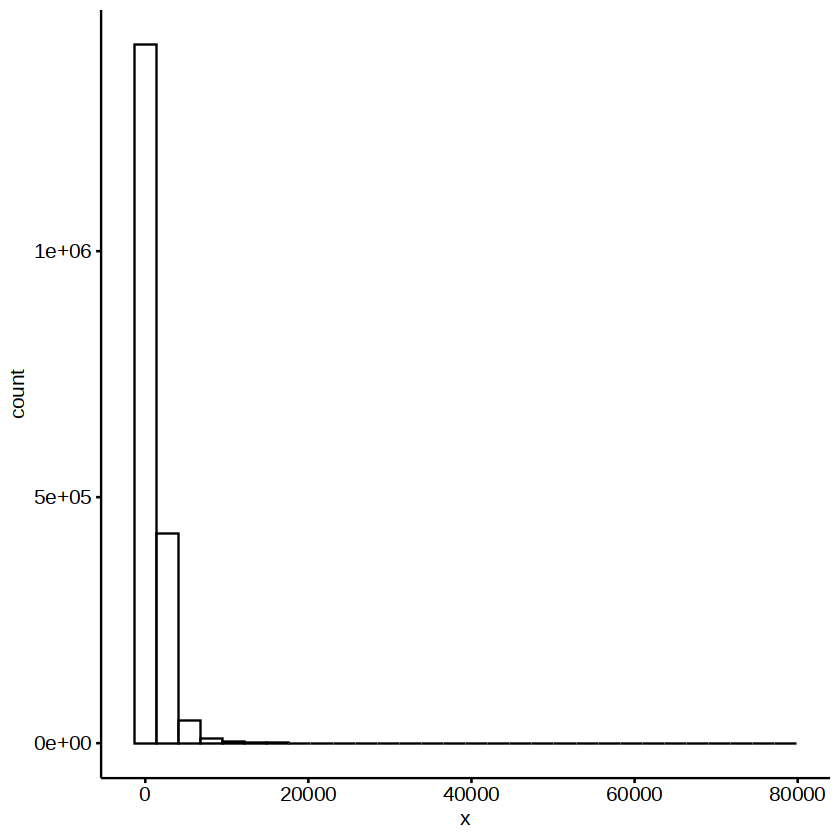

In [37]:
tmp = fread(file.path(getwd(), 'zfp462', beds[3]))[, c(1,2,3)] %>% 
        setnames(c('chr', 'start', 'end'))
    gghistogram(tmp$end - tmp$start) #+ ggtitle(x)

In [38]:
nrow(tmp)

[1] 1903147

In [26]:
summary(test[,10])

      V10         
 Min.   :   50.0  
 1st Qu.:  125.0  
 Median :  150.0  
 Mean   :  285.7  
 3rd Qu.:  325.0  
 Max.   :18775.0  

In [ ]:
foverlaps( , 
         minoverlap = 100)

In [66]:
# Run Macs2 on bedgraph for every ChIP + control
# This only works from BAM files!!

for(i in length(Zfp)){
    tmp = Zfp[[i]]
    cmd = sprintf("macs2 bdgpeakcall -t %s -c %s -g 2.7e9 -n %s --outdir %s",
        file.path(getwd(), gsub('.bw', '.bedgraph', tmp[[1]])),
        file.path(getwd(), gsub('.bw', '.bedgraph', tmp[[2]])),
        paste0('Zfp462_rep', i),
        file.path(getwd(), str_split(tmp[[1]], "/") %>% map_chr(1)))
    # Run command
    system(cmd)
}

In [70]:
i = 1
tmp = Zfp[[i]]
    cmd = sprintf("macs2 bdgpeakcall -t %s -c %s -g 2.7e9 -n %s --outdir %s 2> test.log" ,
        file.path(getwd(), gsub('.bw', '.bedgraph', tmp[[1]])),
        file.path(getwd(), gsub('.bw', '.bedgraph', tmp[[2]])),
        paste0('Zfp462_rep', i),
        file.path(getwd(), str_split(tmp[[1]], "/") %>% map_chr(1)))

In [83]:
tmp = Zfp[[i]]
    cmd = sprintf("macs2 bdgpeakcall -i %s -c 0.05 -o %s 2> test.log" ,
        file.path(getwd(), gsub('.bw', '.bedgraph', tmp[[1]])),
        paste0('Zfp462_rep', i, '.bed'))

In [84]:
cmd

[1] "macs2 bdgpeakcall -i /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP/zfp462/GSM5373686_ZFP462_ChIP_Rep1.bedgraph -c 0.05 -o Zfp462_rep1.bed 2> test.log"

In [85]:
system(cmd)

In [86]:
i = 1
tmp = Zfp[[i]]
    cmd = sprintf("macs2 callpeak -t %s -c %s -g 2.7e9 -n %s --outdir %s 2> test.log" ,
        file.path(getwd(), gsub('.bw', '.bedgraph', tmp[[1]])),
        file.path(getwd(), gsub('.bw', '.bedgraph', tmp[[2]])),
        paste0('Zfp462_rep', i),
        file.path(getwd(), str_split(tmp[[1]], "/") %>% map_chr(1)))

In [87]:
system(cmd)

# Manipulate bigwigs!

In [7]:
library(rtracklayer)


In [8]:
file = file.path(getwd(), Zfp[[1]][[1]])

In [9]:
file2  = file.path(getwd(), Zfp[[1]][[2]])

In [10]:
test = import.bw(BigWigFile(file))

In [11]:
test2 = import.bw(BigWigFile(file2))

In [12]:
bins <- tileGenome(seqinfo(test), tilewidth=20,cut.last.tile.in.chrom=TRUE)

In [13]:
Zfp_rep1 = RleList(
        mclapply(seqlevels(bins),
            function(x) {
            Rle(test[seqnames(test)==x]$score, 
                test[seqnames(test)==x]@ranges@width)
            }, mc.cores=1
        ),
        compress=FALSE)
names(Zfp_rep1) = seqlevels(bins)

In [14]:
Zfp_rep1 = binnedAverage(bins, Zfp_rep1, "avg_score")

In [15]:
input_rep1 = RleList(
        mclapply(seqlevels(bins),
            function(x) {
            Rle(test2[seqnames(test2)==x]$score, 
                test2[seqnames(test2)==x]@ranges@width)
            }, mc.cores=1
        ),
        compress=FALSE)
names(input_rep1) = seqlevels(bins)

In [16]:
input_rep1 = binnedAverage(bins, input_rep1, "avg_score")

In [17]:
Zfp_rep1$input = input_rep1$avg_score

In [18]:
minmax = function(x){
    (x - min(x, na.rm=T))/(max(x, na.rm=T)-min(x, na.rm=T))
}

In [19]:
Zfp_rep1$avg_score = minmax(log2(Zfp_rep1$avg_score+1))
Zfp_rep1$input = minmax(log2(Zfp_rep1$input+1))

In [20]:
Zfp_rep1$difference = log2(Zfp_rep1$avg_score+1)/log2(Zfp_rep1$input+1)
Zfp_rep1$difference = round(Zfp_rep1$difference, 2)
Zfp_rep1[is.na(Zfp_rep1$difference)]$difference = 0
# Zfp_rep1[abs(Zfp_rep1$difference)<0.1]$difference = 0
Zfp_rep1[Zfp_rep1$difference==Inf]$difference = max(Zfp_rep1[Zfp_rep1$difference!=Inf]$avg_score)

In [21]:
summary(Zfp_rep1$difference)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.0000  0.7500  0.7735  1.1800 13.3100 

In [22]:
trial = RleList(
        mclapply(c(paste0('chr', 1:19), 'chrX', 'chrY'),
            function(x) {
            Rle(Zfp_rep1[seqnames(Zfp_rep1)==x]$difference, 
                Zfp_rep1[seqnames(Zfp_rep1)==x]@ranges@width)
            }, mc.cores=1
        ),
        compress=FALSE)
names(trial) = c(paste0('chr', 1:19), 'chrX', 'chrY')

In [23]:
export = trial[,0]
export$score = trial$difference

In [24]:
export(export, file.path(getwd(), 'rep1.bw'))

In [25]:
Zfp_rep1_bu = Zfp_rep1

# Rep2

In [26]:
file = file.path(getwd(), Zfp[[2]][[1]])

In [27]:
file2  = file.path(getwd(), Zfp[[2]][[2]])

In [28]:
test = import.bw(BigWigFile(file))

In [29]:
test2 = import.bw(BigWigFile(file2))

In [30]:
Zfp_rep1 = RleList(
        mclapply(seqlevels(bins),
            function(x) {
            Rle(test[seqnames(test)==x]$score, 
                test[seqnames(test)==x]@ranges@width)
            }, mc.cores=1
        ),
        compress=FALSE)
names(Zfp_rep1) = seqlevels(bins)

In [31]:
Zfp_rep1 = binnedAverage(bins, Zfp_rep1, "avg_score")

In [32]:
input_rep1 = RleList(
        mclapply(seqlevels(bins),
            function(x) {
            Rle(test2[seqnames(test2)==x]$score, 
                test2[seqnames(test2)==x]@ranges@width)
            }, mc.cores=1
        ),
        compress=FALSE)
names(input_rep1) = seqlevels(bins)

In [33]:
input_rep1 = binnedAverage(bins, input_rep1, "avg_score")

In [34]:
Zfp_rep1$input = input_rep1$avg_score

In [35]:
minmax = function(x){
    (x - min(x, na.rm=T))/(max(x, na.rm=T)-min(x, na.rm=T))
}

In [36]:
Zfp_rep1$avg_score = minmax(log2(Zfp_rep1$avg_score+1))
Zfp_rep1$input = minmax(log2(Zfp_rep1$input+1))

In [37]:
Zfp_rep1$difference = log2(Zfp_rep1$avg_score+1)/log2(Zfp_rep1$input+1)
Zfp_rep1$difference = round(Zfp_rep1$difference, 2)
Zfp_rep1[is.na(Zfp_rep1$difference)]$difference = 0
# Zfp_rep1[abs(Zfp_rep1$difference)<0.1]$difference = 0
Zfp_rep1[Zfp_rep1$difference==Inf]$difference = max(Zfp_rep1[Zfp_rep1$difference!=Inf]$avg_score)

In [38]:
summary(Zfp_rep1$difference)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.0000  0.6400  0.7048  1.0500 15.8300 

In [39]:
trial = RleList(
        mclapply(c(paste0('chr', 1:19), 'chrX', 'chrY'),
            function(x) {
            Rle(Zfp_rep1[seqnames(Zfp_rep1)==x]$difference, 
                Zfp_rep1[seqnames(Zfp_rep1)==x]@ranges@width)
            }, mc.cores=1
        ),
        compress=FALSE)
names(trial) = c(paste0('chr', 1:19), 'chrX', 'chrY')

In [40]:
export = trial[,0]
export$score = trial$difference

In [41]:
export(export, file.path(getwd(), 'rep2.bw'))

# multiply

In [42]:
Zfp_rep1
Zfp_rep1_bu

GRanges object with 136276893 ranges and 3 metadata columns:
              seqnames            ranges strand | avg_score     input
                 <Rle>         <IRanges>  <Rle> | <numeric> <numeric>
          [1]    chr10              1-20      * |         0         0
          [2]    chr10             21-40      * |         0         0
          [3]    chr10             41-60      * |         0         0
          [4]    chr10             61-80      * |         0         0
          [5]    chr10            81-100      * |         0         0
          ...      ...               ...    ... .       ...       ...
  [136276889]     chrY 91744601-91744620      * |         0         0
  [136276890]     chrY 91744621-91744640      * |         0         0
  [136276891]     chrY 91744641-91744660      * |         0         0
  [136276892]     chrY 91744661-91744680      * |         0         0
  [136276893]     chrY 91744681-91744698      * |         0         0
              difference
    

GRanges object with 136276893 ranges and 3 metadata columns:
              seqnames            ranges strand | avg_score     input
                 <Rle>         <IRanges>  <Rle> | <numeric> <numeric>
          [1]    chr10              1-20      * |         0         0
          [2]    chr10             21-40      * |         0         0
          [3]    chr10             41-60      * |         0         0
          [4]    chr10             61-80      * |         0         0
          [5]    chr10            81-100      * |         0         0
          ...      ...               ...    ... .       ...       ...
  [136276889]     chrY 91744601-91744620      * |         0         0
  [136276890]     chrY 91744621-91744640      * |         0         0
  [136276891]     chrY 91744641-91744660      * |         0         0
  [136276892]     chrY 91744661-91744680      * |         0         0
  [136276893]     chrY 91744681-91744698      * |         0         0
              difference
    

In [43]:
multiply = Zfp_rep1
multiply$difference = Zfp_rep1$difference * Zfp_rep1_bu$difference

In [44]:
trial = RleList(
        mclapply(c(paste0('chr', 1:19), 'chrX', 'chrY'),
            function(x) {
            Rle(multiply[seqnames(multiply)==x]$difference, 
                multiply[seqnames(multiply)==x]@ranges@width)
            }, mc.cores=1
        ),
        compress=FALSE)
names(trial) = c(paste0('chr', 1:19), 'chrX', 'chrY')

In [45]:
summary(trial$chr1)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.0000  0.5143  0.7669  1.0561 63.9636 

In [46]:
export = multiply[,0]
export$score = multiply$difference

In [47]:
export(export, file.path(getwd(), 'multiply_test.bw'))

# Peak calling over this

In [48]:
# Convert to bedgraph
cmd = sprintf('bigWigToBedGraph %s %s', file.path(getwd(), 'multiply_test.bw'),
             file.path(getwd(), gsub('.bw', '.bedgraph', 'multiply_test.bw')))    
system(cmd)

In [ ]:
    cmd = sprintf("macs2 bdgpeakcall -i %s -c 0.05 -o %s 2> test.log" ,
        file.path(getwd(), gsub('.bw', '.bedgraph', 'multiply_test.bw')),
        paste0('Zfp462.bed'))
    system(cmd)

In [70]:
bed = fread('Zfp462.bed')[,c(1,2,3,5)] %>%
    setnames(c('chr', 'start', 'end', 'signal'))

Warning message in fread("Zfp462.bed"):
“Detected 1 column names but the data has 10 columns (i.e. invalid file). Added 9 extra default column names at the end.”


In [63]:
fwrite(bed[signal>150, c('chr', 'start', 'end')], 'Zfp462_filt.bed', col.names=FALSE, sep='\t')

In [66]:
# Motif search using Homer
cmd = sprintf('/rds/project/rds-SDzz0CATGms/users/bt392/software/homer/bin/findMotifsGenome.pl \
%s/Zfp462_filt.bed mm10 %s/MotifOutput_macs2/ \
-size 150 -S 10 -len 8 -p 24', 
                   getwd(),
                     getwd())

In [72]:
fwrite(bed[signal>100, c('chr', 'start', 'end')], 'Zfp462_filt.bed', col.names=FALSE, sep='\t')
# Motif search using Homer
cmd = sprintf('/rds/project/rds-SDzz0CATGms/users/bt392/software/homer/bin/findMotifsGenome.pl %s/Zfp462_filt.bed mm10 %s/MotifOutput_macs2_100/ -size 150 -S 10 -len 8 -p 24', 
                   getwd(),
                     getwd())
system(cmd)

In [73]:
fwrite(bed[signal>200, c('chr', 'start', 'end')], 'Zfp462_filt.bed', col.names=FALSE, sep='\t')
# Motif search using Homer
cmd = sprintf('/rds/project/rds-SDzz0CATGms/users/bt392/software/homer/bin/findMotifsGenome.pl %s/Zfp462_filt.bed mm10 %s/MotifOutput_macs2_200/ -size 150 -S 10 -len 8 -p 24', 
                   getwd(),
                     getwd())
system(cmd)

In [ ]:
# This doesn't work because it doesn't actually use any statistical cutoff